In [ ]:
"""
Complete evaluation of forecast against different data
"""
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import logging
import argparse
import dataclasses
import xarray as xr
import numpy as np
import pandas as pd
from datetime import datetime
from tqdm import tqdm
import time
import zarr
import matplotlib.pyplot as plt
# import pynvml

import jax
import optax

from graphcast import checkpoint, data_utils, rollout, graphcast, normalization
import save_params_utils
import setup_jax_functions
from plotting import scale, select, plot_data, save_animation, save_static_plot
from metrics import compute_rmse, compute_mae, compute_bias, compute_acc
from utils import regrid_hres_fine_to_coarse, generate_sample_era5_dataset, grads_fn

current_date = datetime.now().strftime("%Y-%m-%d_%H-%M")

# jax.config.update('jax_disable_jit', True)
# for memory efficiency
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE']='false'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '2.0' 
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"]="platform"

mean_by_level = None
stddev_by_level = None
diffs_stddev_by_level = None
model_config = None
task_config = None
params = None
state = None

# ds = xr.open_zarr('/Datastorage/divij.khaitan_asp25/era5/era5_2023_jjas.zarr')

# old_lats = [-90.0, 90.0]
# old_lons = [0.0, 359.0]
# new_lats = np.arange(-90, 90.0 + 1e-8, 1.0)
# new_lons = np.arange(0.0, 359.0 + 1e-8, 1.0)
# new_lats = new_lats[::-1]

# regrid_ds = ds.interp({'latitude': new_lats, 'longitude': new_lons}, 
#                         method='linear',
#                         kwargs={'fill_value': None})

# regrid_ds = regrid_ds.rename({'total_precipitation': 'total_precipitation_6hr'})

# relevant_vars = ['10m_u_component_of_wind',
#  '10m_v_component_of_wind',
#  '2m_temperature',
#  'geopotential',
#  'geopotential_at_surface',
#  'land_sea_mask',
#  'mean_sea_level_pressure',
#  'specific_humidity',
#  'temperature',
#  'total_precipitation_6hr',
#  'u_component_of_wind',
#  'v_component_of_wind',
#  'vertical_velocity']
# relevant_ds = regrid_ds[relevant_vars].copy(deep=True)

# ds_reversed = relevant_ds.sortby('latitude', ascending=True)

# print(f'Relevant times: {ds_reversed.time.min().values} to {ds_reversed.time.max().values}')

# final_ds = ds_reversed
# final_ds['geopotential_at_surface'] = ds_reversed['geopotential_at_surface'].isel(time=0)
# final_ds['land_sea_mask'] = ds_reversed['land_sea_mask'].isel(time=0)




era5_data = xr.open_dataset("/Datastorage/saptarishi.dhanuka_asp25/era5_2015_2022-07-31T18_1deg_37levels.nc")
era5_data_07_08_2022 = era5_data.sel(time=slice('2022-07-01', '2022-07-31'))
# era5_data_07_08_2022


# arco = final_ds


arco  = era5_data_07_08_2022

filename = '/Datastorage/saptarishi.dhanuka_asp25/gc_weights/origs/graphcast_1_13.npz'

# old_lats = arco['latitude'].values
# old_lons = arco['longitude'].values
# new_lats = np.arange(-90.0, 90.0 + 1e-8, 1.0)
# new_lats = np.flip(new_lats)
# new_lons = np.arange(0, 359.75 + 1e-8, 1.0)
# arco = arco.interp({'latitude': new_lats, 'longitude': new_lons}, 
#                         method='linear',
#                         kwargs={'fill_value': None})

input_vars = ['10m_u_component_of_wind',
            'geopotential_at_surface',
            '10m_v_component_of_wind',
            'specific_humidity',
            'land_sea_mask',
            'vertical_velocity',
            'geopotential',
            'v_component_of_wind',
            'temperature',
            'total_precipitation_6hr',
            'mean_sea_level_pressure',
            '2m_temperature',
            'u_component_of_wind']

# arco = arco.drop_vars(['toa_incident_solar_radiation',
# 'year_progress_sin',
# 'year_progress_cos',
# 'day_progress_sin',
# 'day_progress_cos','cos_latitude',
# 'cos_longitude','sin_longitude'])
# arco = arco.rename({'total_precipitation': 'total_precipitation_6hr'})

arco = arco.expand_dims(batch=1)
arco = arco.rename({'latitude': 'lat', 'longitude': 'lon'})

datetime_array = arco['time'].values
# Calculate the time coordinate in 6-hour increments (in nanoseconarco)
time_array = np.arange(0, len(datetime_array) * 21600000000000, 21600000000000, dtype='timedelta64[ns]')

# Add the new 'time' coordinate to the dataset
arco1 = arco.assign_coords(datetime=('time', time_array))

temp_time = arco1.coords["time"].copy()
temp_datetime = arco1.coords["datetime"].copy()

# Reassign the coordinates, swapping their values
arco1 = arco1.assign_coords(
    time=temp_datetime,
    datetime=temp_time
)

# arco1['geopotential_at_surface'] = arco1['geopotential_at_surface'].isel(batch=0, time=0)
# arco1['land_sea_mask'] = arco1['land_sea_mask'].isel(batch=0, time=0)

old_datetime = arco1["datetime"].values  # shape (1489,)

# For our purposes, we want the coordinate to have shape (batch, time). Since the batch
# dimension is of length 1, we can simply add a new axis.
new_datetime = old_datetime[np.newaxis, :]  # shape becomes (1, 1489)

# Now, reassign the "datetime" coordinate to have dims ("batch", "time").
arco1 = arco1.assign_coords(datetime=(("batch", "time"), new_datetime))

print(f"Coordinates after reassigning: {arco1.coords}\n")

select_time = arco1.isel(time=slice(0, 240))
tik = datetime.now()

select_time_eval = arco1.isel(time=slice(7, 71))
select_time_eval

KeyboardInterrupt: 

In [ ]:
def match_dataset_formats(source, target):
    pass

In [ ]:
from dask.diagnostics import ProgressBar

In [ ]:
with ProgressBar():
    eval_trial_batch = select_time_eval.load()

In [ ]:
eval_trial_batch

<xarray.Dataset> Size: 4GB
Dimensions:                  (batch: 1, time: 64, lat: 181, lon: 360, level: 37)
Coordinates:
  * lat                      (lat) float32 724B -90.0 -89.0 -88.0 ... 89.0 90.0
  * level                    (level) int64 296B 1 2 3 5 7 ... 925 950 975 1000
  * lon                      (lon) float32 1kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
    datetime                 (batch, time) datetime64[ns] 512B 2022-07-02T18:...
  * time                     (time) timedelta64[ns] 512B 1 days 18:00:00 ... ...
Dimensions without coordinates: batch
Data variables: (12/13)
    10m_u_component_of_wind  (batch, time, lat, lon) float32 17MB 0.4208 ... ...
    10m_v_component_of_wind  (batch, time, lat, lon) float32 17MB -0.09478 .....
    2m_temperature           (batch, time, lat, lon) float32 17MB 214.0 ... 2...
    geopotential             (batch, time, level, lat, lon) float32 617MB 4.0...
    geopotential_at_surface  (batch, lat, lon) float32 261kB 2.735e+04 ... -0...
    land_sea_mask            (batch, lat, lon) float32 261kB 1.0 1.0 ... 0.0 0.0
    ...                       ...
    specific_humidity        (batch, time, level, lat, lon) float32 617MB 3.8...
    temperature              (batch, time, level, lat, lon) float32 617MB 229...
    total_precipitation_6hr  (batch, time, lat, lon) float32 17MB 1.37e-05 .....
    u_component_of_wind      (batch, time, level, lat, lon) float32 617MB -0....
    v_component_of_wind      (batch, time, level, lat, lon) float32 617MB 0.0...
    vertical_velocity        (batch, time, level, lat, lon) float32 617MB 0.0...

In [ ]:

# eval_trial_batch = select_time_eval.load()

print(f"Eval batch first time: {eval_trial_batch.time.values}")
# training_trial_batch = select_time.load()

tok = datetime.now()
# training_trial_batch = training_trial_batch.rename({'time': 'datetime'})


# with open("/Datastorage/saptarishi.dhanuka_asp25/era5_data/dataset_source-era5_date-2022-01-01_res-1.0_levels-13_steps-40.nc", 'rb') as f:
#     print("Loading Dataset")
#     tik = datetime.now()
#     training_trial_batch = xr.load_dataset(f).compute()
#     # training_trial_batch = training_trial_batch.isel(time=slice(0, 12))
#     # training_trial_batch = training_trial_batch.rename({'time': 'datetime'})
#     print("Training batch time")
#     print(training_trial_batch.datetime)
#     tok = datetime.now()
#     print(f"Dataset loaded in {tok - tik}")


with open(filename, 'rb') as f:
    ckpt = checkpoint.load(f, graphcast.CheckPoint)

params = ckpt.params


with open('/Datastorage/saptarishi.dhanuka_asp25/gc_norms/diffs_stddev_by_level.nc', 'rb') as f:
    diffs_stddev_by_level = xr.load_dataset(f).compute()
with open('/Datastorage/saptarishi.dhanuka_asp25/gc_norms/stddev_by_level.nc', 'rb') as f:
    stddev_by_level = xr.load_dataset(f).compute()
with open('/Datastorage/saptarishi.dhanuka_asp25/gc_norms/mean_by_level.nc', 'rb') as f:
    mean_by_level = xr.load_dataset(f).compute()


state = {}
model_config = ckpt.model_config
task_config = ckpt.task_config
setup_jax_functions.configs['model_config'] = model_config
setup_jax_functions.configs['task_config'] = task_config
setup_jax_functions.configs['state'] = state
setup_jax_functions.configs['params'] = params
setup_jax_functions.configs['stddev_by_level'] = stddev_by_level
setup_jax_functions.configs['diffs_stddev_by_level'] = diffs_stddev_by_level
setup_jax_functions.configs['mean_by_level'] = mean_by_level

setup_jax_functions.update_configs({
'params': ckpt.params,
'state': {},
'model_config': ckpt.model_config,
'task_config': ckpt.task_config,
'mean_by_level': mean_by_level,
'stddev_by_level': stddev_by_level,
'diffs_stddev_by_level': diffs_stddev_by_level
})

init_jitted = jax.jit(setup_jax_functions.with_configs(setup_jax_functions.run_forward.init))
loss_fn_jitted = setup_jax_functions.drop_state(setup_jax_functions.with_params(jax.jit(setup_jax_functions.with_configs(setup_jax_functions.loss_fn.apply))))
grads_fn_jitted = setup_jax_functions.with_params(jax.jit(setup_jax_functions.with_configs(setup_jax_functions.grads_fn)))
run_forward_jitted = setup_jax_functions.drop_state(setup_jax_functions.with_params(jax.jit(setup_jax_functions.with_configs(
setup_jax_functions.run_forward.apply))))

def run_model(params, state, inputs, targets_template, forcings):
    predictions = run_forward_jitted(
    rng=jax.random.PRNGKey(0),
    inputs=inputs,
    targets_template=targets_template,
    forcings=forcings,
    params=params,
    state=state
)
    return predictions

Eval batch first time: [ 151200000000000  172800000000000  194400000000000  216000000000000
  237600000000000  259200000000000  280800000000000  302400000000000
  324000000000000  345600000000000  367200000000000  388800000000000
  410400000000000  432000000000000  453600000000000  475200000000000
  496800000000000  518400000000000  540000000000000  561600000000000
  583200000000000  604800000000000  626400000000000  648000000000000
  669600000000000  691200000000000  712800000000000  734400000000000
  756000000000000  777600000000000  799200000000000  820800000000000
  842400000000000  864000000000000  885600000000000  907200000000000
  928800000000000  950400000000000  972000000000000  993600000000000
 1015200000000000 1036800000000000 1058400000000000 1080000000000000
 1101600000000000 1123200000000000 1144800000000000 1166400000000000
 1188000000000000 1209600000000000 1231200000000000 1252800000000000
 1274400000000000 1296000000000000 1317600000000000 1339200000000000
 1360800000

In [1]:
# need to make sure that the .npz and the .opt are both new and .opt isnt the old one

import os
import numpy as np
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from graphcast import checkpoint, graphcast
new_params_dir = "/Datastorage/saptarishi.dhanuka_asp25/gc_weights/"
params_filename = "graphcast_1_13_orig.npz"
new_params_path = os.path.join(new_params_dir, params_filename)
print(new_params_path)
f = open(new_params_path, "rb")
new_ckpt = checkpoint.load(f, graphcast.CheckPoint)
new_params = new_ckpt.params
f.close()
params_keys_list = list(new_params.keys())
any_not_nan = any(not np.isnan(x) for x in list(new_params[f'{params_keys_list[0]}'].values())[1])
if not any_not_nan:
    print("All values are NaN")
else:
    print("Valid values are there!")

/Datastorage/saptarishi.dhanuka_asp25/gc_weights/graphcast_1_13_orig.npz
Valid values are there!


In [ ]:
time_len = len(eval_trial_batch.time.values)
time_len

64

In [ ]:
jax.config.update("jax_enable_x64", True)

eval_sim_data = eval_trial_batch.isel(time=slice(0, time_len-1))
eval_inputs, eval_targets, eval_forcings = data_utils.extract_inputs_targets_forcings(
eval_sim_data, target_lead_times=slice("6h", "168h"),
**dataclasses.asdict(task_config))

assert eval_trial_batch.sizes["time"] >= 3

print(f"Eval batch time dimensions: {eval_trial_batch.sizes['time']}")

task_config_dict =  dataclasses.asdict(task_config)

print("Eval Inputs:   ", eval_inputs.dims.mapping)
print("Eval Targets:  ", eval_targets.dims.mapping)
print("Eval Forcings: ", eval_forcings.dims.mapping)

targets_template = eval_targets * np.nan

print("Running old params")
predictions_old = run_model(params, state, eval_inputs, targets_template, eval_forcings)

print("Predictions Old: ", predictions_old.dims.mapping)

print("Running new params")

predictions_finetuned = run_model(new_params, state, eval_inputs, targets_template, eval_forcings)
print("Predictions Finetuned: ", predictions_finetuned.dims.mapping)

Eval batch time dimensions: 64
Eval Inputs:    {'batch': 1, 'time': 2, 'lat': 181, 'lon': 360, 'level': 13}
Eval Targets:   {'batch': 1, 'time': 28, 'lat': 181, 'lon': 360, 'level': 13}
Eval Forcings:  {'batch': 1, 'time': 28, 'lat': 181, 'lon': 360}
Running old params
Predictions Old:  {'time': 28, 'batch': 1, 'lat': 181, 'lon': 360, 'level': 13}
Running new params
Predictions Finetuned:  {'time': 28, 'batch': 1, 'lat': 181, 'lon': 360, 'level': 13}


In [ ]:
predictions_old.to_netcdf(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_old_india_2023_6.nc")
predictions_finetuned.to_netcdf(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_finetuned_india2023_6.nc")

In [ ]:
def plot_sample_from_ds(ds, var_name, time_index=0):
    ds.isel(time=0)['total_precipitation_6hr'].plot()

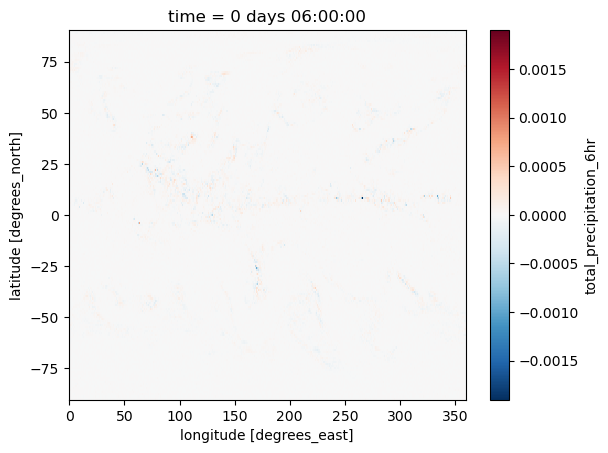

In [ ]:
plot_sample_from_ds(predictions_finetuned-predictions_old, '2m_temperature', time_index=0)

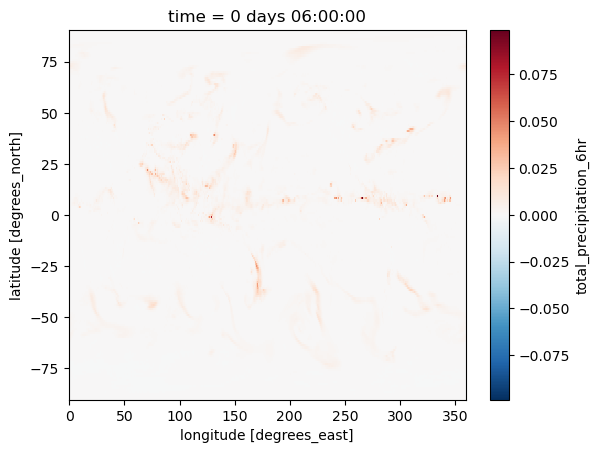

In [ ]:
predictions_old.isel(time=0)['total_precipitation_6hr'].plot()

In [ ]:
imd_jun23_forecast = xr.open_dataset('/Datastorage/saptarishi.dhanuka_asp25/imd_tigge_2023_07.grib')
imd_jun23_forecast

/home/saptarishi.dhanuka_asp25/.conda/envs/graphcast_fine/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(


<xarray.Dataset> Size: 290MB
Dimensions:     (time: 31, step: 9, latitude: 361, longitude: 720)
Coordinates:
    number      int64 8B ...
  * time        (time) datetime64[ns] 248B 2023-07-01 2023-07-02 ... 2023-07-31
  * step        (step) timedelta64[ns] 72B 0 days 00:00:00 ... 2 days 00:00:00
    surface     float64 8B ...
  * latitude    (latitude) float64 3kB 90.0 89.5 89.0 88.5 ... -89.0 -89.5 -90.0
  * longitude   (longitude) float64 6kB 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5
    valid_time  (time, step) datetime64[ns] 2kB ...
Data variables:
    tp          (time, step, latitude, longitude) float32 290MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             vabb
    GRIB_centreDescription:  New Delhi
    GRIB_subCentre:          2
    Conventions:             CF-1.7
    institution:             New Delhi
    history:                 2025-06-24T21:21 GRIB to CDM+CF via cfgrib-0.9.1...

In [ ]:
select_time_eval.datetime.values[0]

array(['2023-07-01T00:00:00.000000000', '2023-07-01T06:00:00.000000000',
       '2023-07-01T12:00:00.000000000', '2023-07-01T18:00:00.000000000',
       '2023-07-02T00:00:00.000000000', '2023-07-02T06:00:00.000000000',
       '2023-07-02T12:00:00.000000000', '2023-07-02T18:00:00.000000000',
       '2023-07-03T00:00:00.000000000', '2023-07-03T06:00:00.000000000',
       '2023-07-03T12:00:00.000000000', '2023-07-03T18:00:00.000000000',
       '2023-07-04T00:00:00.000000000', '2023-07-04T06:00:00.000000000',
       '2023-07-04T12:00:00.000000000', '2023-07-04T18:00:00.000000000',
       '2023-07-05T00:00:00.000000000', '2023-07-05T06:00:00.000000000',
       '2023-07-05T12:00:00.000000000', '2023-07-05T18:00:00.000000000',
       '2023-07-06T00:00:00.000000000', '2023-07-06T06:00:00.000000000',
       '2023-07-06T12:00:00.000000000', '2023-07-06T18:00:00.000000000',
       '2023-07-07T00:00:00.000000000', '2023-07-07T06:00:00.000000000',
       '2023-07-07T12:00:00.000000000', '2023-07-07

In [ ]:
init_date = select_time_eval.datetime.values[0][0]

In [ ]:
init_date

numpy.datetime64('2023-07-01T00:00:00.000000000')

In [ ]:
imd_jun23_temp = imd_jun23_forecast.sel(time=init_date)
imd_jun23_temp

<xarray.Dataset> Size: 9MB
Dimensions:     (step: 9, latitude: 361, longitude: 720)
Coordinates:
    number      int64 8B ...
    time        datetime64[ns] 8B 2023-07-01
  * step        (step) timedelta64[ns] 72B 0 days 00:00:00 ... 2 days 00:00:00
    surface     float64 8B ...
  * latitude    (latitude) float64 3kB 90.0 89.5 89.0 88.5 ... -89.0 -89.5 -90.0
  * longitude   (longitude) float64 6kB 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5
    valid_time  (step) datetime64[ns] 72B ...
Data variables:
    tp          (step, latitude, longitude) float32 9MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             vabb
    GRIB_centreDescription:  New Delhi
    GRIB_subCentre:          2
    Conventions:             CF-1.7
    institution:             New Delhi
    history:                 2025-06-24T21:21 GRIB to CDM+CF via cfgrib-0.9.1...

In [ ]:
imd_6h_converted = ( imd_jun23_temp.isel(step=0+1) ['tp'] - imd_jun23_temp.isel(step=0) ['tp'] )/1000

In [ ]:
hres = xr.open_dataset('/Datastorage/saptarishi.dhanuka_asp25/forecasts_hres/raw_hres/2022/hres_2022_8_1_ppt.grib')
hres

/home/saptarishi.dhanuka_asp25/.conda/envs/graphcast_fine/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(


<xarray.Dataset> Size: 317MB
Dimensions:     (step: 8, values: 6599680)
Coordinates:
    number      int64 8B ...
    time        datetime64[ns] 8B ...
  * step        (step) timedelta64[ns] 64B 00:00:00 06:00:00 ... 1 days 18:00:00
    surface     float64 8B ...
    latitude    (values) float64 53MB ...
    longitude   (values) float64 53MB ...
    valid_time  (step) datetime64[ns] 64B ...
Dimensions without coordinates: values
Data variables:
    tp          (step, values) float32 211MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-06-25T13:22 GRIB to CDM+CF via cfgrib-0.9.1...

In [ ]:
regridded_hres = regrid_hres_fine_to_coarse(hres, variable='tp', coarse_resolution=1.0)
regridded_hres

Regridding tp from high resolution to coarse resolution 1.0 degrees
Regridder built


<xarray.DataArray 'tp' (step: 8, lat: 181, lon: 360)> Size: 2MB
array([[[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        ...,
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00]],

       [[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
...
        [4.6539307e-04, 4.6539307e-04, 4.8828125e-04, ...,
         4.1198730e-04, 4.1198730e-04, 4.6539307e-04],
        [2.5177002e-04, 2.5177002e-04, 2.5177002e-04, ...,
         2.4414062e-04, 2.5177002e-04, 2.5177002e-04],
        [2.5177002e-04, 2.5177002e-04, 2.5177002e-04, ...,
         2.5177002e-04, 2.5177002e-04, 2.5177002e-04]],

       [[2.9754639e-04, 2.9754639e-04, 2.9754639e-04, ...,
         2.9754639e-04, 2.9754639e-04, 2.9754639e-04],
        [3.5095215e-04, 3.5095215e-04, 3.5095215e-04, ...,
         3.4332275e-04, 3.5095215e-04, 3.5095215e-04],
        [3.9672852e-04, 3.9672852e-04, 3.8909912e-04, ...,
         3.9672852e-04, 3.9672852e-04, 3.9672852e-04],
        ...,
        [5.0354004e-04, 5.0354004e-04, 5.1116943e-04, ...,
         4.5776367e-04, 4.5776367e-04, 5.0354004e-04],
        [4.3487549e-04, 4.3487549e-04, 4.3487549e-04, ...,
         4.4250488e-04, 4.3487549e-04, 4.3487549e-04],
        [3.1280518e-04, 3.1280518e-04, 3.1280518e-04, ...,
         3.1280518e-04, 3.1280518e-04, 3.1280518e-04]]], dtype=float32)
Coordinates:
    number      int64 8B 0
    time        datetime64[ns] 8B 2022-08-01
  * step        (step) timedelta64[ns] 64B 00:00:00 06:00:00 ... 1 days 18:00:00
    surface     float64 8B 0.0
    valid_time  (step) datetime64[ns] 64B 2022-08-01 ... 2022-08-02T18:00:00
  * lat         (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 88.0 89.0 90.0
  * lon         (lon) float64 3kB 0.0 1.0 2.0 3.0 ... 356.0 357.0 358.0 359.0
Attributes: (12/23)
    GRIB_paramId:                    228
    GRIB_dataType:                   fc
    GRIB_numberOfPoints:             6599680
    GRIB_typeOfLevel:                surface
    GRIB_stepUnits:                  1
    GRIB_stepType:                   instant
    ...                              ...
    GRIB_totalNumber:                0
    GRIB_units:                      m
    long_name:                       Total precipitation
    units:                           m
    standard_name:                   unknown
    regrid_method:                   nearest_s2d


Shape of the 6-hour forecast data from ds1: (181, 360)
Shape of the hourly 'tp' data from ds2: (8, 181, 360)

Step 3: Calculating Mean Squared Error per step...

Calculated MSE for each step:
<xarray.DataArray (step: 8)> Size: 64B
array([1.59605183e-07, 3.42381869e-07, 8.06818294e-07, 1.51353187e-06,
       2.44103698e-06, 3.59758161e-06, 4.86975060e-06, 6.30794471e-06])
Coordinates:
  * step        (step) timedelta64[ns] 64B 00:00:00 01:00:00 ... 07:00:00
    number      int64 8B 0
    surface     float64 8B 0.0
    valid_time  (step) datetime64[ns] 64B 2022-07-01 ... 2022-07-01T07:00:00

Step 4: Plotting the results...


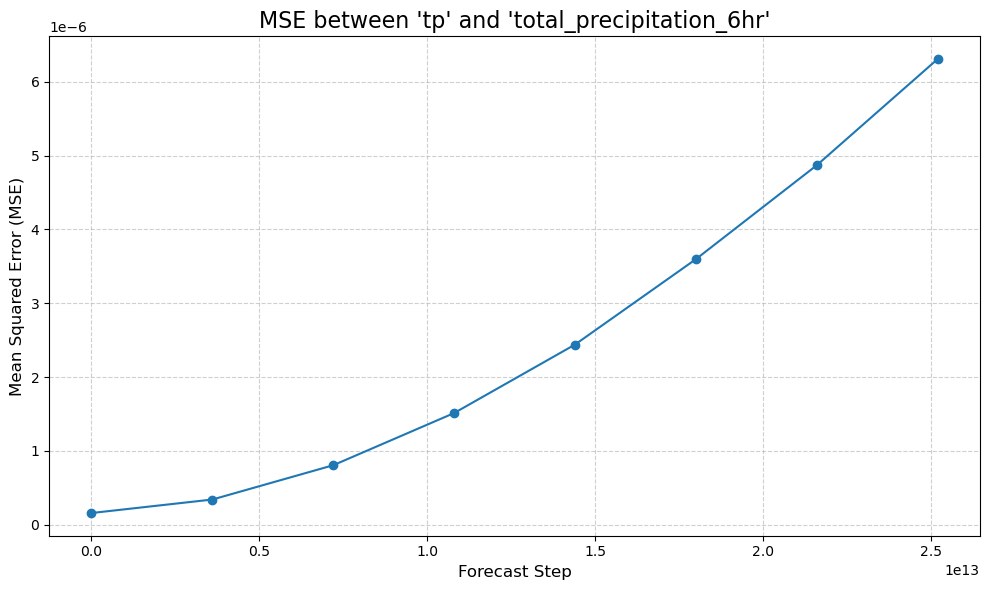

In [ ]:
precip_ds1 = eval_targets['total_precipitation_6hr']

# Select the data at the 6-hour mark.
# We use .sel() to select by coordinate value.
six_hour_forecast = precip_ds1.sel(time=pd.to_timedelta('6 hours'))

# The result has a 'batch' dimension of size 1. We remove it with .squeeze()
# so its dimensions (lat, lon) match the spatial dimensions of ds2.
six_hour_forecast_squeezed = six_hour_forecast.squeeze('batch')

# The second dataset is already our target variable 'tp'
precip_ds2 = regridded_hres

print("\nShape of the 6-hour forecast data from ds1:", six_hour_forecast_squeezed.shape)
print("Shape of the hourly 'tp' data from ds2:", precip_ds2.shape)


# --- 3. Compute the Mean Squared Error (MSE) ---
print("\nStep 3: Calculating Mean Squared Error per step...")

# Xarray will automatically align and broadcast the 'six_hour_forecast_squeezed' array
# across the 'step' dimension of 'precip_ds2' during the subtraction.
squared_error = (six_hour_forecast_squeezed - precip_ds2)**2

# Now, compute the mean over the spatial dimensions ('lat', 'lon') to get
# a single MSE value for each step.
mse_per_step = squared_error.mean(dim=['lat', 'lon'])

print("\nCalculated MSE for each step:")
print(mse_per_step)


# --- 4. Plot the Results ---
print("\nStep 4: Plotting the results...")

# Create the plot
plt.figure(figsize=(10, 6))

# Use xarray's built-in plotting for a quick and easy line plot
mse_per_step.plot.line(marker='o', linestyle='-')

# Customize the plot for clarity
plt.title("MSE between 'tp' and 'total_precipitation_6hr'", fontsize=16)

# The step coordinate is a timedelta; we can format the x-axis for readability
# by getting the total hours from the timedelta coordinate.
x_labels = mse_per_step.step.dt.total_seconds() / 3600
# plt.xticks(mse_per_step.step, labels=[f'{int(h)}h' for h in x_labels])
plt.xlabel("Forecast Step", fontsize=12)
plt.ylabel("Mean Squared Error (MSE)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Show the plot
plt.show()

In [ ]:
mse_per_step.values

array([1.59605183e-07, 3.42381869e-07, 8.06818294e-07, 1.51353187e-06,
       2.44103698e-06, 3.59758161e-06, 4.86975060e-06, 6.30794471e-06])

In [ ]:
import cartopy.crs as ccrs
import xarray as xr

latmax = 38
latmin = 6
lonmin = 68
lonmax = 98

def plot_difference_with_targets_fine_sims(preds_finetuned, targets, time_step, var_name):
    fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    extent = [68, 98, 6, 38]  # Focus on India

    temperature_pred_finetuned = preds_finetuned[var_name]
    temperature_targets = targets[var_name]

    # Difference between finetuned predictions and evaluation targets
    temp_finetuned = temperature_pred_finetuned.isel(time=time_step).sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).squeeze()
    temp_targets = temperature_targets.isel(time=time_step).sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).squeeze()
    difference = temp_finetuned - temp_targets

    difference.plot.pcolormesh(
        ax=ax, transform=ccrs.PlateCarree(), cmap='bwr',
        cbar_kwargs={'label': 'Temperature Difference (K)'})
    ax.set_extent(extent)
    ax.coastlines()
    ax.set_title(f"Finetuned Prediction vs Ground Truth at Time Step {time_step}")

    plt.tight_layout()
    plt.savefig(f'plotsnew/training/difference_finetuned{time_step}_imerg_2.png')
    plt.close()

    return (difference)



def plot_difference_with_targets_base_sims(preds_old, targets, time_step, var_name):
    fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    extent = [68, 98, 6, 38]  # Focus on India

    temperature_pred_old = preds_old[var_name]
    temperature_targets = targets[var_name]

    # Difference between finetuned predictions and evaluation targets
    temp_base = temperature_pred_old.isel(time=time_step).sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).squeeze()
    temp_targets = temperature_targets.isel(time=time_step).sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).squeeze()
    difference = temp_base - temp_targets

    difference.plot.pcolormesh(
        ax=ax, transform=ccrs.PlateCarree(), cmap='bwr',
        cbar_kwargs={'label': 'Temperature Difference (K)'})
    ax.set_extent(extent)
    ax.coastlines()
    ax.set_title(f"Finetuned Prediction vs Ground Truth at Time Step {time_step}")

    plt.tight_layout()
    plt.savefig(f'plotsnew/training/difference_base{time_step}_imerg_2.png')
    plt.close()

    return (difference)


def plot_diff_imd_era5_sims(pred_imd, targets, time_step, var_name):
    fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    extent = [68, 98, 6, 38]  # Focus on India

    # if var_name == 'total_precipitation_6hr':
    #     pred_imd = preds_old['tp']
        
    temperature_targets = targets[var_name]

    # imd lat order is reversed

    pred_imd = pred_imd.rename({'latitude': 'lat', 'longitude': 'lon'})
    temp_imd = pred_imd.sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).squeeze()
    temp_targets = temperature_targets.isel(time=time_step,batch=0).sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).squeeze()
    difference = temp_imd - temp_targets

    difference.plot.pcolormesh(
        ax=ax, transform=ccrs.PlateCarree(), cmap='bwr',
        cbar_kwargs={'label': 'Temperature Difference (K)'})
    ax.set_extent(extent)
    ax.coastlines()
    ax.set_title(f"IMD Prediction vs Ground Truth at Time Step {time_step} for {var_name}")

    plt.tight_layout()
    plt.savefig(f'plotsnew/training/difference_imd_era5_{var_name}_2.png')
    plt.close()

    return (difference)

In [ ]:
diff_fine, diff_old, diff_imd = [], [], []

In [ ]:
for time_step in tqdm(range(4)):
    diff_fine.append(plot_difference_with_targets_fine_sims(predictions_finetuned,eval_targets,time_step, 'total_precipitation_6hr'))
    diff_old.append(plot_difference_with_targets_base_sims(predictions_old,eval_targets,time_step, 'total_precipitation_6hr'))
    diff_imd.append(plot_diff_imd_era5_sims(imd_6h_converted,eval_targets,time_step, 'total_precipitation_6hr'))


100%|██████████| 4/4 [00:01<00:00,  2.69it/s]


In [ ]:
def compute_mse(predictions, targets):
    return ((predictions - targets) ** 2).mean()

def compute_mse_diffs(diff):
    return (diff ** 2).mean(dim=["lat", "lon"]).values

[array(1.30338009e-06), array(9.66576661e-06), array(1.04822204e-05), array(1.28963753e-05)]
[array(nan), array(nan), array(nan), array(nan)]


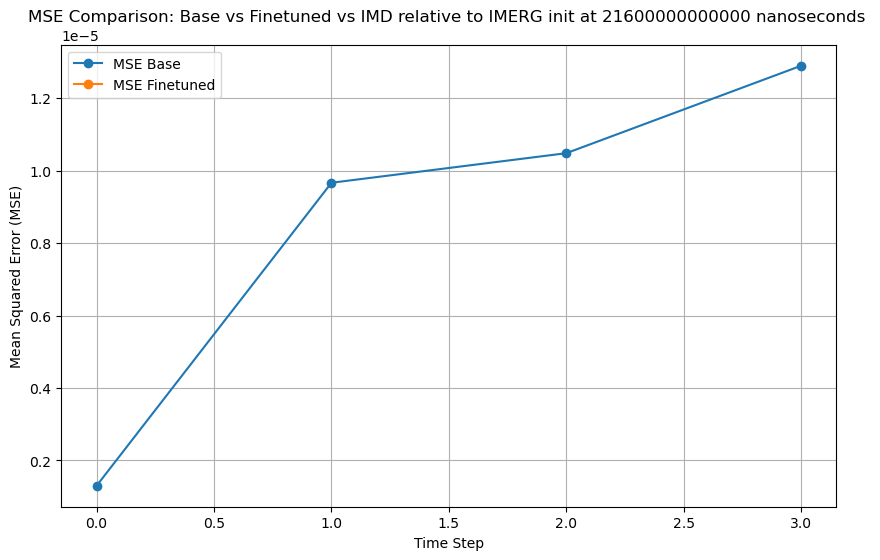

In [ ]:
# Compute the MSE for each time step and aggregate
mse_finetuned = []
mse_base = []
mse_imd_era5 = []
for diff_counter in range(len(diff_fine)):
    mse_diff_finetuned = compute_mse_diffs(diff_fine[diff_counter])
    mse_diff_base = compute_mse_diffs(diff_old[diff_counter])
    # mse_diff_imd_era5 = compute_mse_diffs(differences_era5_imd[diff_counter])
    
    mse_finetuned.append(mse_diff_finetuned)
    mse_base.append(mse_diff_base)
    # mse_imd_era5.append(mse_diff_imd_era5)

# print(mse_base)
# print()
# print(mse_finetuned)


print(mse_base)
print(mse_finetuned)




# Plot the line chart
plt.figure(figsize=(10, 6))
plt.plot(list(range(4)), mse_base, label='MSE Base', marker='o')
plt.plot(list(range(4)), mse_finetuned, label='MSE Finetuned', marker='o')
# plt.plot(list(range(4)), mse_imd_era5, label='MSE IMD', marker='o')
# plt.plot(time_steps, mse_imd_era5, label='MSE IMD ERA5', marker='x')

    # Annotate the first and last points for MSE Base
# plt.annotate(f"{mse_base[0]:.4f}", (0, mse_base[0]), textcoords="offset points", xytext=(-10, 10), ha='center')
# plt.annotate(f"{mse_base[-1]:.4f}", (6, mse_base[-1]), textcoords="offset points", xytext=(-10, 10), ha='center')


# Add labels, title, and legend
plt.xlabel('Time Step')
plt.ylabel('Mean Squared Error (MSE)')
plt.title(f'MSE Comparison: Base vs Finetuned vs IMD relative to IMERG init at {eval_targets.time.values[0]} ')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

In [ ]:
mse_diff_finetuned = compute_mse_diffs(a)
mse_diff_base = compute_mse_diffs(b)
mse_diff_imd_era5 = compute_mse_diffs(c)